<a href="https://colab.research.google.com/github/nandinirathod1767-ship-it/Assignment-17/blob/main/Assignment_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from google.colab import files
uploaded = files.upload()

Saving Salary Prediction dataset.csv to Salary Prediction dataset (2).csv


In [23]:
filepath='/content/Salary Prediction dataset.csv'
df=pd.read_csv(filepath)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [ ]:
df = pd.read_csv("Salary Prediction dataset.csv")   # Load the dataset

print("Display first 10 row")
df.head(10)

Display first 10 row


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


In [ ]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
}))

# Handle missing values (remove rows with missing values)
df = df.dropna()

print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

                     Missing Values  Percentage (%)
Age                               2        0.533333
Gender                            2        0.533333
Education Level                   2        0.533333
Job Title                         2        0.533333
Years of Experience               2        0.533333
Salary                            2        0.533333
Duplicate Rows: 49
Dataset Shape: (324, 6)


In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [ ]:
df["Salary"].max()

250000.0

In [ ]:
df["Salary"].max()

250000.0

In [ ]:
df["Salary"].mean()

np.float64(99985.64814814815)

In [ ]:
print("")
df["Salary"].median()


In [ ]:
# Target variable: salary
print("Minimum salary:", df["Salary"].min())
print("Maximum salary:", df["Salary"].max())
print("Mean salary:", df["Salary"].mean())
print("Median Salary:", df["Salary"].median())

Minimum salary: 350.0
Maximum salary: 250000.0
Mean salary: 99985.64814814815
Median Salary: 95000.0


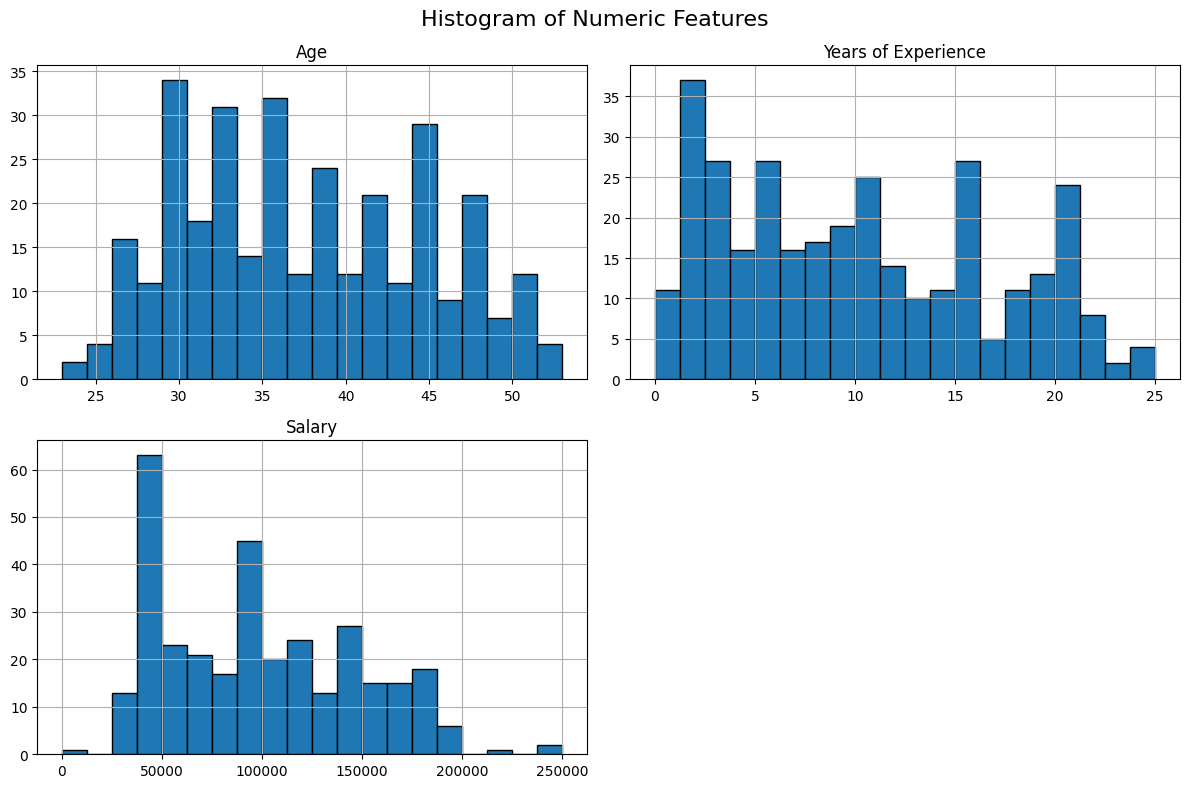

In [ ]:
# Select numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_columns].hist(figsize=(12, 8), bins=20, edgecolor='black')

plt.suptitle("Histogram of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

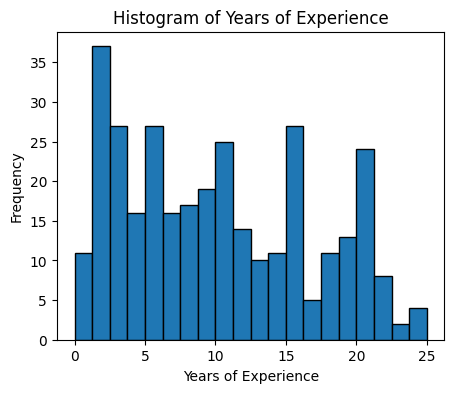

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(df["Years of Experience"], bins=20, edgecolor="black")
plt.title("Histogram of Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Frequency")
plt.show()

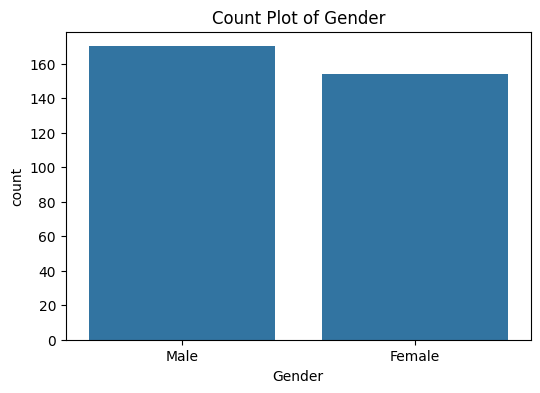

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title("Count Plot of Gender")
plt.show()

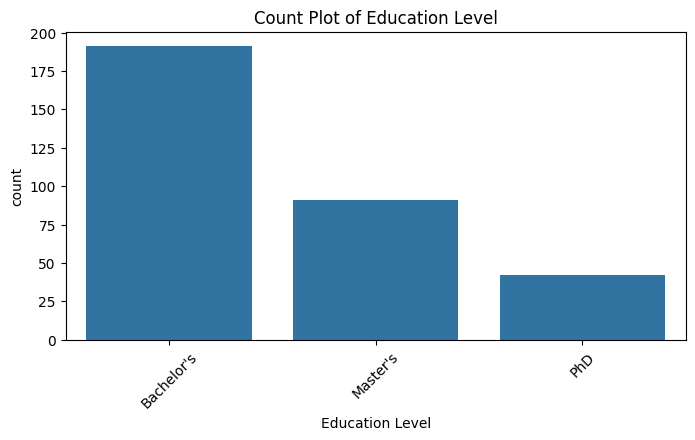

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Education Level')
plt.title("Count Plot of Education Level")
plt.xticks(rotation=45)
plt.show()

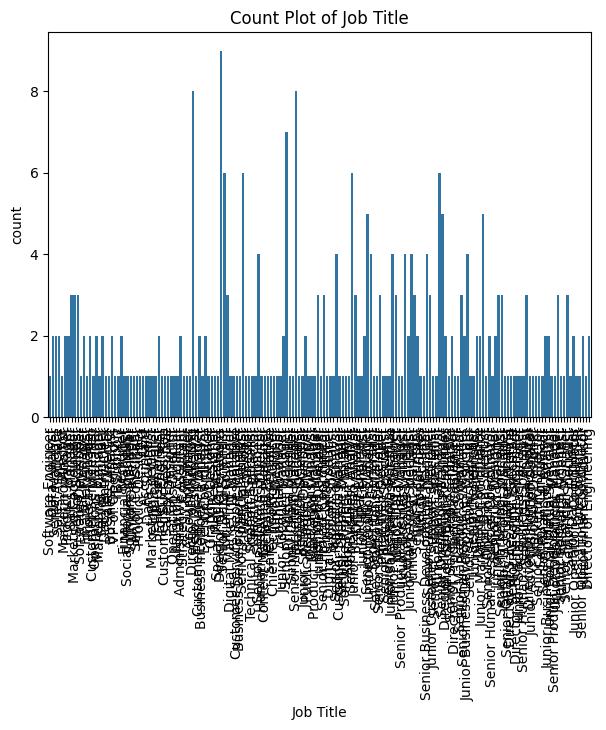

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Job Title')
plt.title("Count Plot of Job Title")
plt.xticks(rotation=90)
plt.show()

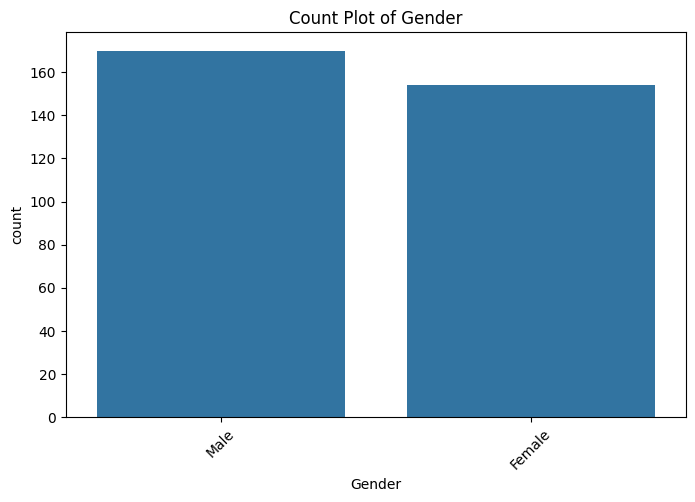

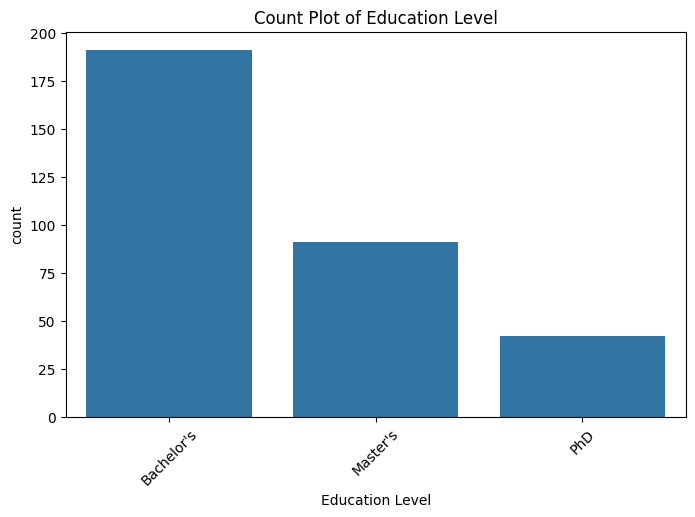

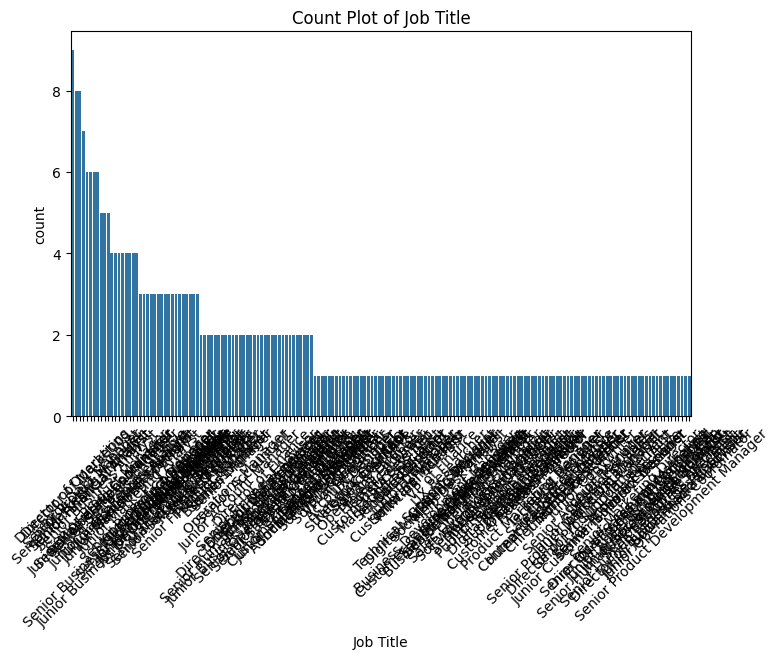

In [ ]:
# Select categorical columns
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()


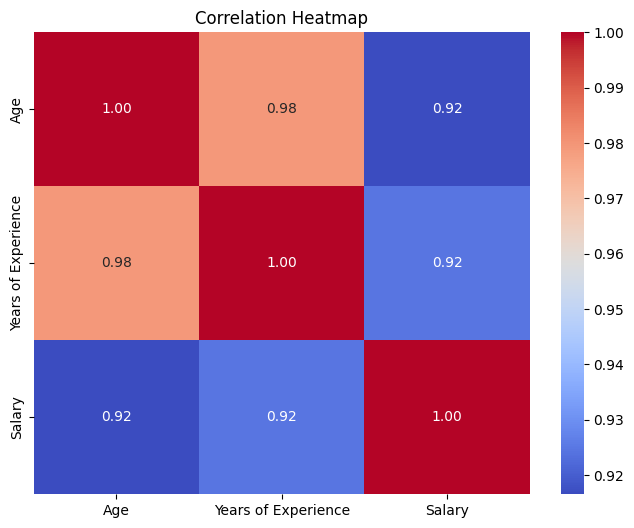

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Correlation of all features with Salary
salary_corr = corr_matrix["Salary"].sort_values(ascending=False)

print("Correlation with Salary:")
print(salary_corr)

Correlation with Salary:
Salary                 1.000000
Years of Experience    0.924455
Age                    0.916543
Name: Salary, dtype: float64


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

print("\nBefore Encoding:")
print(df[['Gender', 'Education Level']].head())


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nAfter Encoding (Gender):")
print(df_encoded.filter(regex='Gender').head())

print("\nAfter Encoding (Education Level):")
print(df_encoded.filter(regex='Education Level').head())

Categorical Columns:
Index(['Gender', 'Education Level', 'Job Title'], dtype='object')

Before Encoding:
   Gender Education Level
0    Male      Bachelor's
1  Female        Master's
2    Male             PhD
3  Female      Bachelor's
4    Male        Master's

After Encoding (Gender):
   Gender_Male
0         True
1        False
2         True
3        False
4         True

After Encoding (Education Level):
   Education Level_Master's  Education Level_PhD
0                     False                False
1                      True                False
2                     False                 True
3                     False                False
4                      True                False


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Salary', axis=1)

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)# Convert scaled data into a DataFrame

print("First 5 Rows of Scaled Features:")
print(X_scaled_df.head())

First 5 Rows of Scaled Features:
        Age  Years of Experience  Gender_Male  Education Level_Master's  \
0 -0.750231            -0.761821     0.951779                 -0.624946   
1 -1.307742            -1.063017    -1.050665                  1.600137   
2  1.061680             0.744158     0.951779                 -0.624946   
3 -0.192720            -0.460625    -1.050665                 -0.624946   
4  2.037324             1.497148     0.951779                  1.600137   

   Education Level_PhD  Job Title_Accountant  \
0            -0.385922             -0.055641   
1            -0.385922             -0.055641   
2             2.591194             -0.055641   
3            -0.385922             -0.055641   
4            -0.385922             -0.055641   

   Job Title_Administrative Assistant  Job Title_Business Analyst  \
0                           -0.078811                   -0.078811   
1                           -0.078811                   -0.078811   
2                   

In [ ]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')